In [43]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from collections import Counter
import itertools
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [21]:
# Load dataset
df = pd.read_csv(r'C:\Bits-Sems\Bits-Sem2\twitter_sentiment_data.csv')
df.head()

,sentiment,message,tweetid
0,-1,@tiniebeany climate change is an interesting h...,792927353886371840
1,1,RT @NatGeoChannel: Watch #BeforeTheFlood right...,793124211518832641
2,1,Fabulous! Leonardo #DiCaprio's film on #climat...,793124402388832256
3,1,RT @Mick_Fanning: Just watched this amazing do...,793124635873275904
4,2,"RT @cnalive: Pranita Biswasi, a Lutheran from ...",793125156185137153


In [9]:
#Download NLTK dataset
nltk.download('punkt')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sajal\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sajal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove URLs, mentions, hashtags, and non-alphabet characters
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|#\w+', '', text) 
    text = re.sub(r'[^a-z\s]', '', text)  
    
    # Tokenize and remove stopwords
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and word.strip() != '']
    return ' '.join(tokens)


In [23]:
# Apply cleaning
df['message'] = df['message'].apply(clean_text)
df.head(5)

,sentiment,message,tweetid
0,-1,climate change interesting hustle global warmi...,792927353886371840
1,1,rt watch right travels world tackle climate ch...,793124211518832641
2,1,fabulous leonardo film change brilliant watch via,793124402388832256
3,1,rt watched amazing documentary leonardodicapri...,793124635873275904
4,2,rt pranita biswasi lutheran odisha gives testi...,793125156185137153


In [25]:
df.rename(columns={'message': 'Tweets'}, inplace=True)

In [27]:
df.head(5)

,sentiment,Tweets,tweetid
0,-1,climate change interesting hustle global warmi...,792927353886371840
1,1,rt watch right travels world tackle climate ch...,793124211518832641
2,1,fabulous leonardo film change brilliant watch via,793124402388832256
3,1,rt watched amazing documentary leonardodicapri...,793124635873275904
4,2,rt pranita biswasi lutheran odisha gives testi...,793125156185137153


In [29]:
# Remove 'tweetid' column if present
if 'tweetid' in df.columns:
    df = df.drop(columns=['tweetid'])

In [54]:
num_tweets = len(df)
print("Number of tweets in the dataset:", num_tweets)

Number of tweets in the dataset: 43943


In [35]:
# Tokenize all cleaned tweets
tokenized_tweets = [text.split() for text in df['Tweets'] if text.strip() != '']

# Flatten to get all words
all_words = list(itertools.chain.from_iterable(tokenized_tweets))
word_freq = Counter(all_words)
most_common = word_freq.most_common(2)
second_most_common_word = most_common[1][0]  # index 0 = most common, 1 = second


In [37]:
# Get top 5 most common words
top_5 = word_freq.most_common(5)

print("Top 5 most frequent words:")
for i, (word, freq) in enumerate(top_5, 1):
    print(f"{i}. '{word}': {freq}")

Top 5 most frequent words:
1. 'climate': 34036
2. 'change': 33874
3. 'rt': 25304
4. 'global': 10800
5. 'warming': 10026


In [39]:
#2nd Most common word 
most_common = word_freq.most_common(2)
second_most_common_word = most_common[1][0]  
print("Second most frequent word:", second_most_common_word)
print("Frequency:", most_common[1][1])

Second most frequent word: change
Frequency: 33874


In [70]:
# CBOW (sg=0)
model_cbow = Word2Vec(sentences=tokenized_tweets, vector_size=100, window=5, min_count=1, sg=0, workers=4)

# Skip-Gram (sg=1)
model_sg = Word2Vec(sentences=tokenized_tweets, vector_size=100, window=5, min_count=1, sg=1, workers=4)

# Get embeddings
embedding_cbow = model_cbow.wv[second_most_common_word]
embedding_sg = model_sg.wv[second_most_common_word]

print("\nCBOW embedding for 2nd Frequent Word(first 10 dims):", second_most_common_word,' - ',embedding_cbow[:10])
print("Skip-Gram embedding for 2nd Frequent Word(first 10 dims):", second_most_common_word,' - ',embedding_sg[:10])


CBOW embedding for 2nd Frequent Word(first 10 dims): change  -  [ 0.02822331  0.5811492  -0.55505455  0.11822593  1.345189   -1.343838
  0.35993412  1.6426466   0.0193093  -1.0488191 ]
Skip-Gram embedding for 2nd Frequent Word(first 10 dims): change  -  [-2.1147719e-01  5.8599347e-01  1.7911212e-01  1.0090558e-01
  1.3255899e-01 -3.0150798e-01  6.8285932e-05  3.2407483e-01
 -3.8582173e-01 -1.4995679e-01]


The vector_size=100 parameter defines the number of dimensions in the word embedding space that means each word is represented as a 100-dimensional real-valued vector. This value was chosen based on a balance between model capacity and data constraints:-

Expressiveness: A dimensionality of 100 is sufficiently large to capture meaningful semantic and syntactic relationships between words (e.g., similarity between climate and global warming), which is essential for downstream NLP tasks like sentiment analysis.

Data Efficiency: Our dataset contains approximately 43943 tweets — a moderate-sized corpus. Larger embedding sizes (e.g., 300 or 500, as used in models like Word2Vec-GoogleNews) require significantly more data to estimate reliable vector representations. With limited data, higher dimensions lead to overfitting and sparse learning, where many dimensions remain under-trained.

Computational Trade-off:
Low dimensionality (e.g., 20–50) may underfit, failing to encode nuanced relationships.
High dimensionality (e.g., 300+) increases memory usage and training time, with diminishing returns on small datasets.
100 dimensions strikes an optimal trade-off: it preserves semantic richness while remaining computationally feasible and statistically reliable for this corpus size.

The window=5 parameter in Word2Vec defines the maximum distance (in words) between the target word and its surrounding context words during training. A window size of 5 means the model considers up to 5 words before and 5 words after the target word as its context.

This value is chosen because:

1) Standard Practice: window=5 is a widely accepted default in Word2Vec implementations and works well for general English text.
Tweet-Specific Suitability: Tweets are short (typically 10–20 words). A window of 5 captures most of the relevant local context without including irrelevant or distant words that could add noise.
2) Semantic Coherence: Words within ±5 positions usually share strong semantic or syntactic relationships (e.g., “climate change is real” → “change” is highly informative for “climate”), which helps the model learn meaningful embeddings.
3) Trade-off Balance:
A smaller window (e.g., 2–3) focuses on syntactic relations (e.g., noun-adjective pairs).
A larger window (e.g., 10+) captures broader topical similarity but may dilute local meaning.
Window=5 strikes a balance, capturing both local semantics and moderate context—ideal for sentiment-related tasks like this one.
Thus, window=5 is a theoretically and empirically justified choice for training word embeddings on tweet-length social media text.

The min_count=1 parameter in Word2Vec specifies that all words appearing at least once in the corpus should be included in the vocabulary and trained as part of the embedding model.
This value is choosen because:-
1) Preservation of All Words: Since the task requires identifying and analyzing the second most frequent word, using a higher min_count (e.g., 2, 5, or 10) could accidentally exclude words that appear only once or twice—potentially altering word frequency rankings or even excluding the target word if the dataset distribution is skewed.
2) Small-to-Moderate Dataset: With 43943 tweets, many meaningful content words (e.g., domain-specific terms like “paris”, “cop26”) may occur infrequently. Aggressively filtering them would harm semantic coverage.
3) Trade-off:
Downside: Including rare words (with very few contexts) leads to noisy or unstable embeddings, as the model has insufficient examples to learn reliable representations.
Upside: For analysis-focused tasks (like this assignment), completeness of vocabulary is prioritized over embedding quality for rare words—especially since we’re analyzing a high-frequency word.

In [62]:
def plot_similar_words(model, word, title):
    similar_words = model.wv.most_similar(word, topn=10)
    words = [word] + [w for w, _ in similar_words]
    vectors = [model.wv[w] for w in words]

    # Reduce to 2D
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(vectors)

    plt.figure(figsize=(14, 10))
    plt.scatter(reduced[:, 0], reduced[:, 1])
    for i, w in enumerate(words):
        plt.annotate(w, xy=(reduced[i, 0], reduced[i, 1]), fontsize=10)
    plt.title(title)
    plt.grid(True)
    plt.show()

Word2Vec embeddings are high-dimensional. But we can’t plot 100D points directly on a 2D graph (like a notebook or screen). So, PCA is used to: Compress the 100-dimensional vectors into 2 dimensions, While preserving as much variance (information) as possible, So we can visualize the relative positions of words and their semantic similarity.

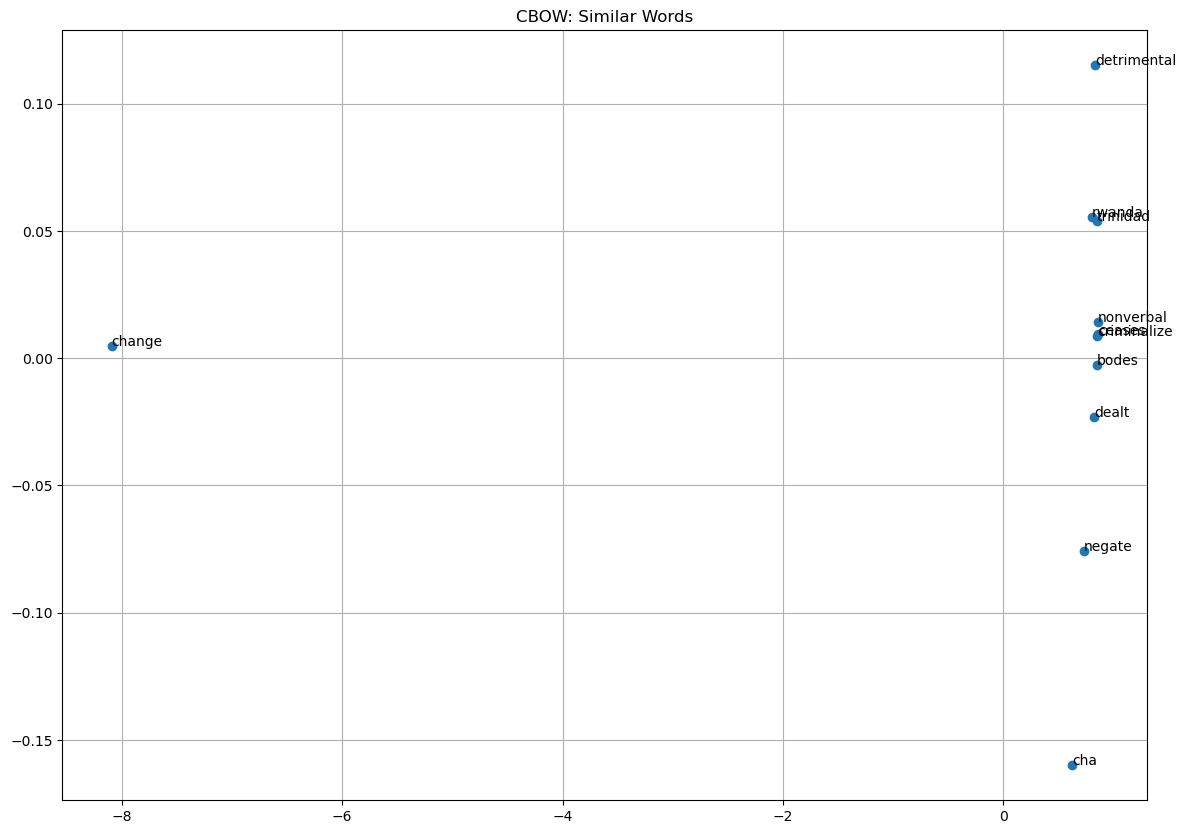

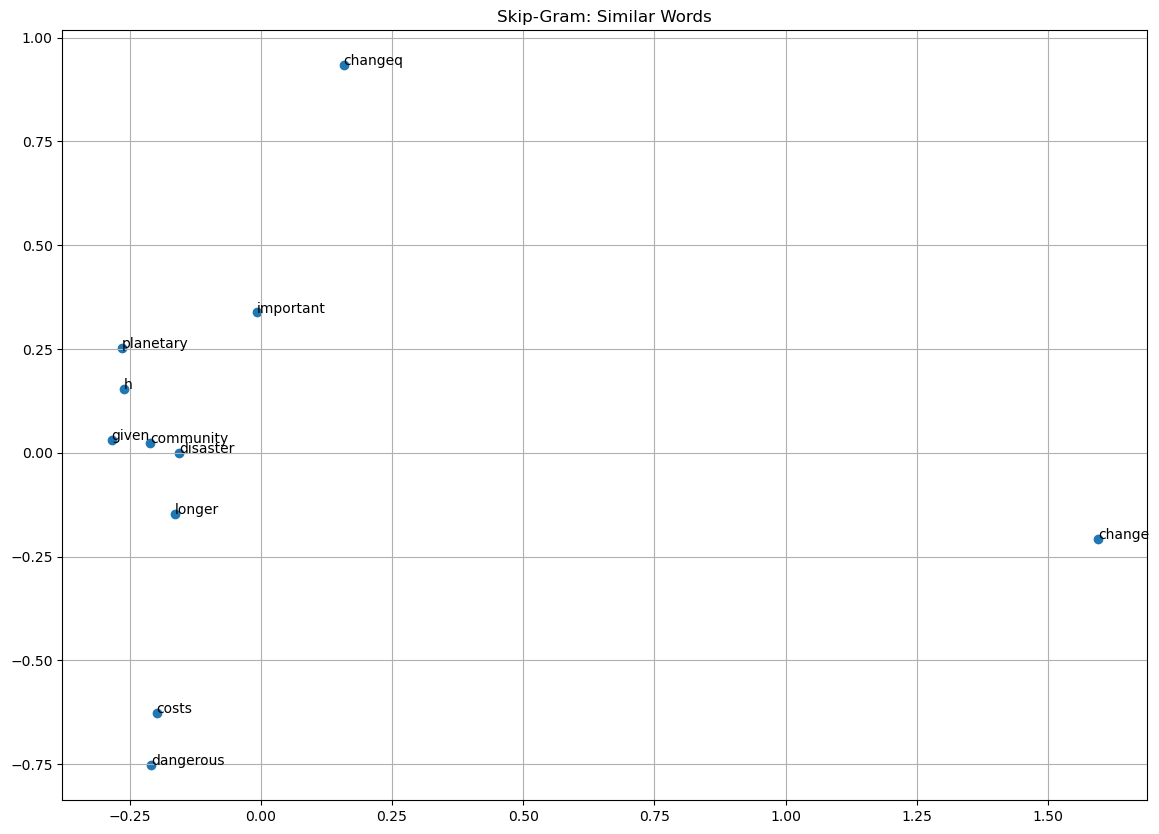

In [64]:
plot_similar_words(model_cbow, second_most_common_word, "CBOW: Similar Words")
plot_similar_words(model_sg, second_most_common_word, "Skip-Gram: Similar Words")

Observations about CBOW and SkipGram:-
1) Semantic Clustering vs. Dispersion CBOW Plot: The similar words (e.g., detrimental, nonverbal, bodes, negate) appear to be clustered more tightly around the central word (change). This suggests CBOW creates smoother, more generalized embeddings where semantically related words are pulled closer together. Skip-Gram Plot: The similar words (e.g., important, planetary, disaster, dangerous) are more dispersed across the 2D space. This reflects Skip-Gram’s tendency to capture finer-grained, context-specific relationships, often leading to a wider spread of neighbors.
2) Nature of Similar Words:- In the CBOW visualization, the top similar words include terms like detrimental, negate, dealt — many of which are negative or action-oriented. This might indicate that CBOW is associating “change” with its consequences or outcomes in the context of climate tweets. In the Skip-Gram visualization, words like important, planetary, disaster, dangerous suggest associations with scale, urgency, or impact. This aligns with Skip-Gram’s strength in capturing contextual roles — e.g., “climate change is important”, “planetary crisis”.
3) Word Positioning and Context Sensitivity:- The word change itself appears in different positions relative to its neighbors in each plot. In CBOW, it’s near the center of a vertical cluster; in Skip-Gram, it’s off to the right, almost isolated from other points. Some words (like cha in CBOW or h in Skip-Gram) appear as outliers — likely due to being rare, misspelled, or noisy tokens after cleaning.
4) Suitability for Downstream Tasks:-For tasks requiring general semantic understanding (e.g., topic modeling, broad sentiment classification), CBOW’s tighter clustering might be preferable. For tasks needing fine-grained contextual awareness (e.g., detecting sarcasm, identifying specific arguments in climate debates), Skip-Gram’s dispersed yet context-rich neighbors could provide richer signals.

Count-based embeddings (e.g., TF-IDF, PPMI, LSA) construct word representations using global statistical information from a document-term co-occurrence matrix. These methods count how often words appear together in documents or contexts and apply transformations (like log or SVD) to reduce dimensionality and noise. They are deterministic, interpretable, and fast to compute, but the resulting vectors are often high-dimensional and sparse, which limits their ability to capture nuanced semantic relationships.

Prediction-based embeddings (e.g., Word2Vec’s CBOW and Skip-Gram, GloVe*) learn dense, low-dimensional vectors by training a neural network to predict a word from its context (CBOW) or context from a word (Skip-Gram). These models capture local context patterns and implicitly encode semantic and syntactic analogies (e.g., king – man + woman ≈ queen). Though computationally more expensive and stochastic, they produce robust, generalizable representations that perform well on downstream NLP tasks like sentiment analysis, named entity recognition, and machine translation.
Comparision:-
Sparsity: Count-based is sparse but Prediction-based is dense.
Semantics: Count-based capture surface-level topic similarity but Prediction-based capture deeper analogical and contextual semantics.
Scalability: Count-based struggle with vocabulary growth but  Prediction-based scale better with large corpora.
Training: Count-based are computed directly from statistics but Prediction-based require iterative optimization.